In [ ]:
import torch
import geopandas as gpd

from dotenv import load_dotenv
import os

import shapely
load_dotenv()
import random
import numpy as np



try:
    RANDOM_SEED = int(os.environ["RANDOM_SEED"])
except:
    RANDOM_SEED = 15


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



gdf = gpd.read_file("../../gpkgs/bda_2024_patches_2024_classified.gpkg")

aez_number_to_class_label = {}
with open("LR/aez/AEZ_57classes.clr", "r") as infile:
    for line in infile:
        parts = line.strip().split()
        aez_number_to_class_label[int(parts[0])] = " ".join(parts[5:])

aez_number_to_class_label[0] = "Unclassified"

fold_assignments = {
    "train": [0,1,2],
    "valid": [4],
    "test": [5]
}

sample_count = 500


/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7622a5f741f0>>
Traceback (most recent call last):
  File "/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
sampled_gdf = gdf.groupby('fold', group_keys=False).apply(
       lambda x: x.sample(n=min(sample_count, len(x)), random_state=RANDOM_SEED)
   )

sampled_gdf = sampled_gdf[sampled_gdf["fold"] != -1]

/tmp/ipykernel_67508/819812860.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_gdf = gdf.groupby('fold', group_keys=False).apply(


In [ ]:
len(sampled_gdf)

2500

<Axes: >

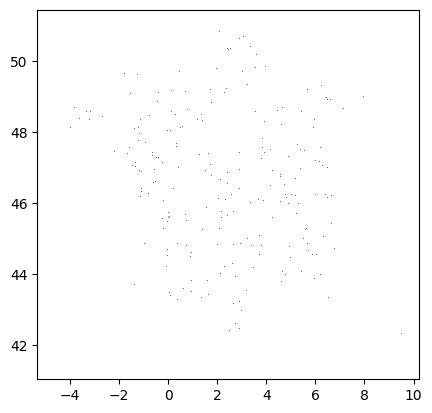

In [ ]:
sampled_gdf.plot()

In [ ]:
sampled_gdf.to_file("../../gpkgs/hedgementation_dataset_1.0.gpkg")


In [ ]:
sampled_gdf["hedgerow_area"] = (
    gpd.GeoSeries(shapely.wkt.loads(sampled_gdf["hedgerows"]), crs="EPSG:4326")
    .to_crs("EPSG:3857")
    .apply(lambda geom: shapely.buffer(geom, 0.35).area)
)

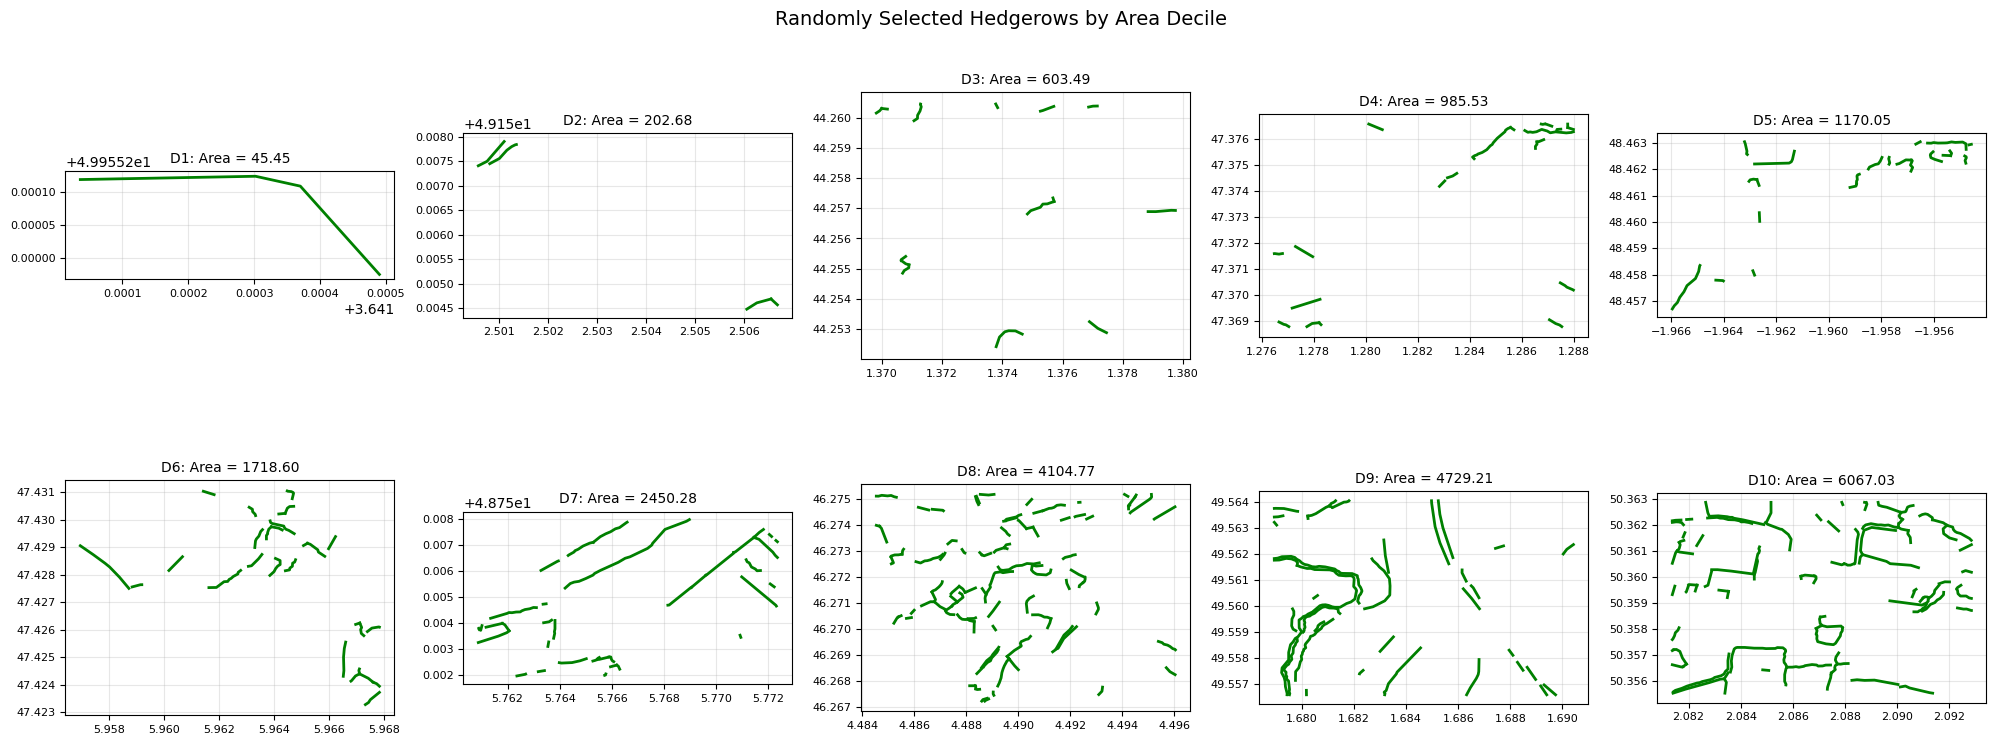


Decile Summary:
D1: Area = 45.4484
D2: Area = 202.6824
D3: Area = 603.4912
D4: Area = 985.5291
D5: Area = 1170.0475
D6: Area = 1718.6004
D7: Area = 2450.2801
D8: Area = 4104.7663
D9: Area = 4729.2114
D10: Area = 6067.0343


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
import pandas as pd
import numpy as np

# Load the hedgerow geometries from WKT strings
sampled_gdf['geometry'] = sampled_gdf['hedgerows'].apply(wkt.loads)

# Calculate deciles of hedgerow_area
deciles = np.percentile(sampled_gdf['hedgerow_area'], np.arange(0, 100, 10))
decile_labels = [f'D{i+1}' for i in range(10)]

# Assign each hedgerow to a decile bin
sampled_gdf['decile'] = pd.cut(sampled_gdf['hedgerow_area'], 
                                bins=np.append(deciles, sampled_gdf['hedgerow_area'].max() + 1),
                                labels=decile_labels,
                                include_lowest=True)

# Randomly sample one hedgerow from each decile
sampled_hedgerows = []
for decile in decile_labels:
    decile_data = sampled_gdf[sampled_gdf['decile'] == decile]
    if len(decile_data) > 0:
        sample = decile_data.sample(n=1).iloc[0]
        sampled_hedgerows.append({
            'decile': decile,
            'geometry': sample['geometry'],
            'area': sample['hedgerow_area']
        })

# Create the plot
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, hedgerow in enumerate(sampled_hedgerows):
    ax = axes[idx]
    
    # Plot the hedgerow
    if hedgerow['geometry'].geom_type == 'MultiLineString':
        for line in hedgerow['geometry'].geoms:
            x, y = line.xy
            ax.plot(x, y, 'g-', linewidth=2)
    else:  # Single LineString
        x, y = hedgerow['geometry'].xy
        ax.plot(x, y, 'g-', linewidth=2)
    
    ax.set_title(f"{hedgerow['decile']}: Area = {hedgerow['area']:.2f}", fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.suptitle('Randomly Selected Hedgerows by Area Decile', 
             fontsize=14, y=1.002)
plt.show()

# Print summary statistics
print("\nDecile Summary:")
for hedgerow in sampled_hedgerows:
    print(f"{hedgerow['decile']}: Area = {hedgerow['area']:.4f}")

In [ ]:
big = sampled_gdf[sampled_gdf["hedgerow_area"] > sampled_gdf["hedgerow_area"].quantile(0.99)]
print(len(big))

big.to_file("../../gpkgs/bda_2024_patches_2024_classified_large_area.gpkg")


25
